Saving df_file.csv to df_file (1).csv
Accuracy: 97.07865168539325%


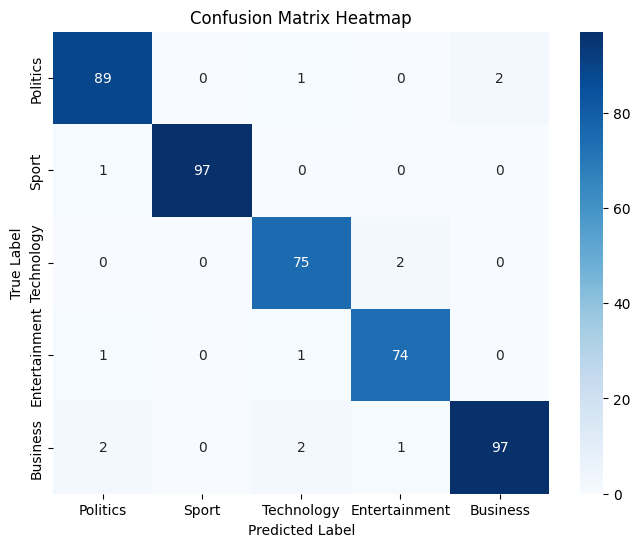

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload the dataset file
uploaded = files.upload()

data = pd.read_csv('df_file.csv')
X = data['Text']
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

y_pred = model.predict(X_test_vectorized)

label_mapping = {
    0: 'Politics',
    1: 'Sport',
    2: 'Technology',
    3: 'Entertainment',
    4: 'Business'
}

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy *100}%')


class_labels = np.unique(y_test)
# Use the label_mapping for plotting
mapped_class_labels = [label_mapping[label] for label in class_labels]

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=mapped_class_labels, yticklabels=mapped_class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [28]:

print(X)
print(y)

0       Budget to set scene for election\n \n Gordon B...
1       Army chiefs in regiments decision\n \n Militar...
2       Howard denies split over ID cards\n \n Michael...
3       Observers to monitor UK election\n \n Minister...
4       Kilroy names election seat target\n \n Ex-chat...
                              ...                        
2220    India opens skies to competition\n \n India wi...
2221    Yukos bankruptcy 'not US matter'\n \n Russian ...
2222    Survey confirms property slowdown\n \n Governm...
2223    High fuel prices hit BA's profits\n \n British...
2224    US trade gap hits record in 2004\n \n The gap ...
Name: Text, Length: 2225, dtype: object
0       0
1       0
2       0
3       0
4       0
       ..
2220    4
2221    4
2222    4
2223    4
2224    4
Name: Label, Length: 2225, dtype: int64


In [51]:
user_input = ("I love artificial intelligence and machine learning")

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{label_mapping[predicted_label[0]]}' category.")

The input text belongs to the 'Technology' category.


In [54]:
user_input = ("The meeting held with so much of entertainments")
user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{label_mapping[predicted_label[0]]}' category.")

The input text belongs to the 'Politics' category.


In [53]:
user_input = ("the whole cricket fans where all upto the keen winning of rajasthan royals")
user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{label_mapping[predicted_label[0]]}' category.")

The input text belongs to the 'Sport' category.


In [52]:
user_input = ("in whole india if we look the cjp party is having majority vote")
user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{label_mapping[predicted_label[0]]}' category.")

The input text belongs to the 'Politics' category.
